# Create Images of Ship Sprites

In [3]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:60% !important; }</style>"))

Load in the sprite data

In [4]:
import re
from colors_map import *

sprites_files = ["uridium/src/ship_sprites.asm"]
sprites_data = {}
for sprites_file in sprites_files:
    input_file = open(sprites_file,'r')
    sprite_data = []
    for l in input_file.readlines():
        if "SPRITE" in l:
            if sprite_data:
                sprites_data[sprite_name] = sprite_data
            sprite_name = l[22:36].strip()
            sprite_data = []
            continue

        m = re.findall(r"[0-1]{24}",l)
        if not m:
            continue
        bits = m[0]
        sprite_line = []
        for i in range(0,23,2):
            bitpair = bits[i:i+2]
            sprite_line += [bitpair]
            sprite_line += [bitpair]
        sprite_data += [sprite_line]
    if sprite_data:
        sprites_data[sprite_name] = sprite_data

Function for actually drawing the sprite

In [5]:
from PIL import Image, ImageColor, ImageFont, ImageDraw
SPRITE_COLS = 24
SPRITE_ROWS = 21
CELL_WIDTH = 40
CELL_HEIGHT = 40

def paintSprite(sprite, colors):
    multicol0, multicol1,color = colors
    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    
    if sprite not in sprites_data:
        print(sprite)
        return
    
    image_width = SPRITE_COLS
    image_height = SPRITE_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    pixels = img.load()

    bit_array = sprites_data[sprite]
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "00":
                continue
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            pixels[x,y] = pixel_color
    return img


In [6]:
from PIL import Image, ImageFilter, ImageColor

resize = lambda img,factor: img.resize((int(img.width * factor), int(img.height * factor)), Image.NEAREST)

def addBlackOutline(img):
    stroke_radius = 5
    stroke_image = Image.new("RGBA", img.size, (0, 0, 0, 255))
    img_alpha = img.getchannel(3).point(lambda x: 255 if x>0 else 0)
    stroke_alpha = img_alpha.filter(ImageFilter.MaxFilter(stroke_radius))
    # optionally, smooth the result
    stroke_alpha = stroke_alpha.filter(ImageFilter.SMOOTH)
    stroke_image.putalpha(stroke_alpha)
    output = Image.alpha_composite(stroke_image, img)
    return output

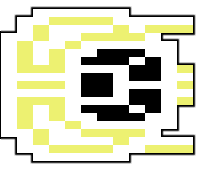

In [7]:
colors = (
    # cell color, text color
     "c64_yellow",
     "c64_white",
     "c64_black", 
)
sprite_images = []
for sprite_name in sprites_data:
    img = paintSprite(sprite_name, colors)
    sprite = resize(img, 8)
    img = Image.new( 'RGBA', (sprite.width+2, sprite.height+2))
    img.paste(sprite, (1,1))
    img = addBlackOutline(img)
    sprite_images += [img]
    if sprite_name:
        img.save(f"manta_spin_diagrams/{sprite_name}.png")
sprite_images[1]

## A graphic showing the spin animation

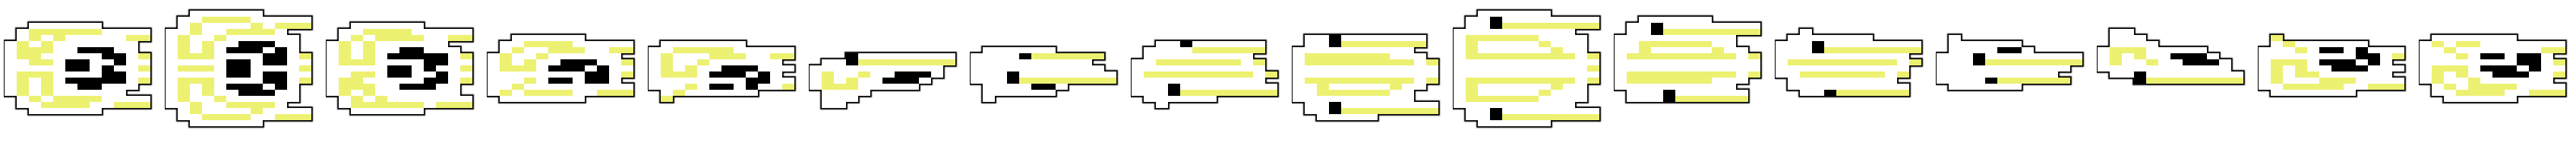

In [8]:
master_width = ((sprite_images[1].width + 10) * 16)
master_height = sprite_images[1].height + 10
master_img = Image.new( 'RGBA', (master_width, master_height))
x_offset = 5
for img in sprite_images[:16] + [sprite_images[0]]:
    master_img.paste(img, (x_offset,5))
    x_offset += sprite_images[1].width  + 10
#master_img = master_img.resize((master_img.width * 10, master_img.height * 10), Image.NEAREST)
master_img.save("manta_spin_diagrams/manta_spin.png")
master_img

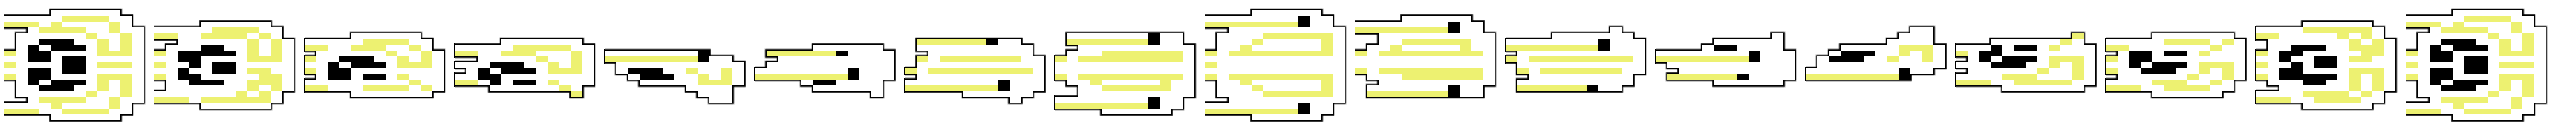

In [9]:
master_width = ((sprite_images[1].width + 20) * 16)
master_img = Image.new( 'RGBA', (master_width, master_height))
x_offset = 5
for img in sprite_images[25:32] + sprite_images[16:26]:
    master_img.paste(img, (x_offset,5))
    x_offset += sprite_images[1].width  + 5
#master_img = master_img.resize((master_img.width * 10, master_img.height * 10), Image.NEAREST)
master_img.save("manta_spin_diagrams/manta_spin_left.png")
master_img

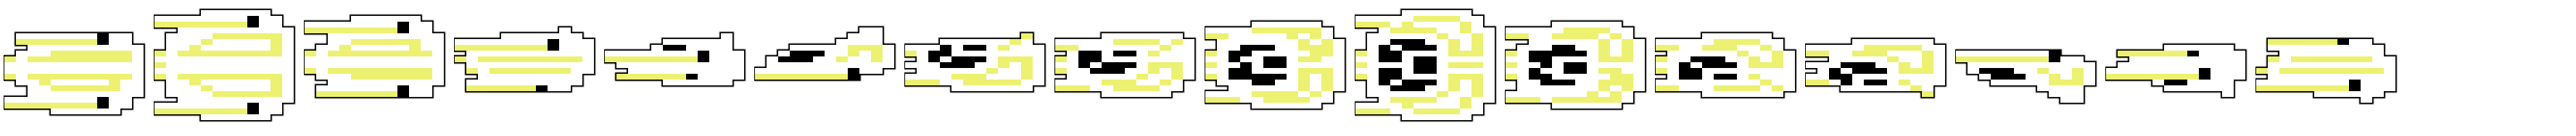

In [10]:
master_img = Image.new( 'RGBA', (master_width, master_height))
x_offset = 5
for img in sprite_images[16:32]:
    master_img.paste(img, (x_offset,5))
    x_offset += sprite_images[1].width + 5
#master_img = master_img.resize((master_img.width * 10, master_img.height * 10), Image.NEAREST)
master_img.save("manta_spin_diagrams/manta_spin_left_contiguous.png")
master_img

### Iterative Graphic of the Spin Animation

In [11]:
all_sprites = sprite_images[:16] + [sprite_images[0]]
for i in range(1,17):
    master_width = ((sprite_images[1].width + 20) * i)
    master_height = sprite_images[1].height + 10
    master_img = Image.new( 'RGBA', (master_width, master_height))
    x_offset = 5
    scoped_sprites = all_sprites[:i]
    for img in scoped_sprites:
        master_img.paste(img, (x_offset,5))
        x_offset += sprite_images[1].width + 20
    #master_img = master_img.resize((master_img.width * 10, master_img.height * 10), Image.NEAREST)
    master_img.save(f"manta_spin_diagrams/manta_spin_{i}.png")


### Last two sprites of each animation

In [12]:
all_sprites = sprite_images[:16] + [sprite_images[0]]
for i in range(2,17):
    master_width = ((sprite_images[1].width + 20) * 2)
    master_height = sprite_images[1].height + 10
    master_img = Image.new( 'RGBA', (master_width, master_height))
    x_offset = 5
    scoped_sprites = all_sprites[i-2:i]
    for img in scoped_sprites:
        master_img.paste(img, (x_offset,5))
        x_offset += sprite_images[1].width + 20
    #master_img = master_img.resize((master_img.width * 10, master_img.height * 10), Image.NEAREST)
    master_img.save(f"manta_spin_diagrams/manta_spin_last_two_{i}.png")


### Intervening Frames

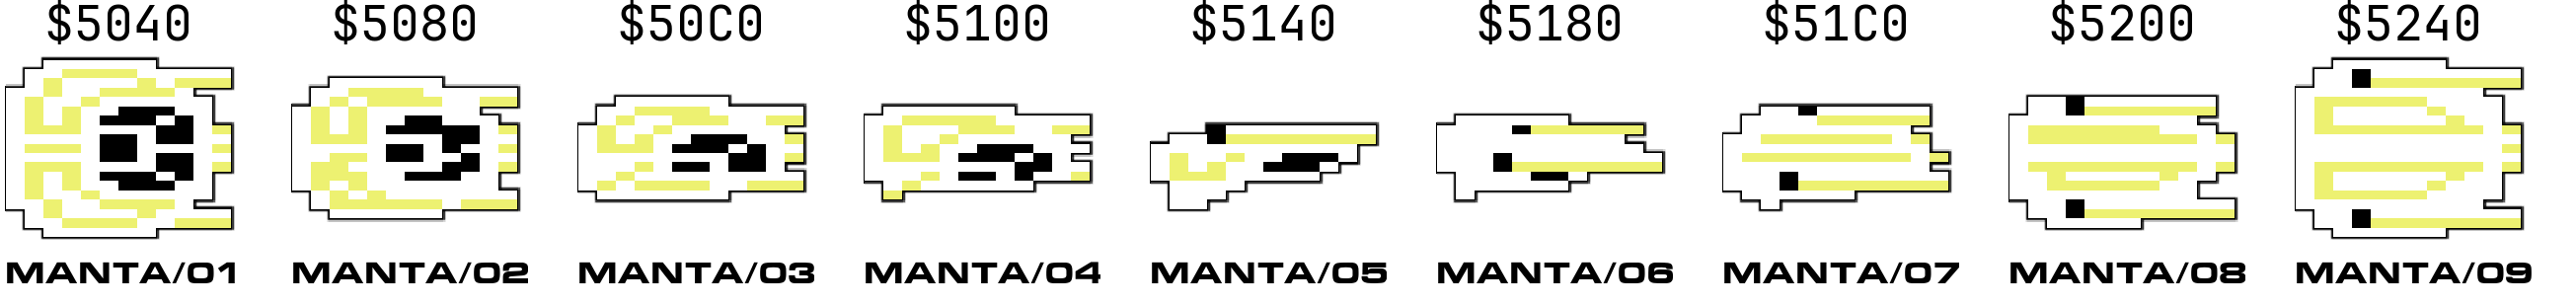

In [24]:
SPRITE_COLS = 24
SPRITE_ROWS = 21
CELL_WIDTH = 40
CELL_HEIGHT = 40

PADDING = 50
SCALE = 10
SPRITE_WIDTH_SCALED = SPRITE_COLS * SCALE
SPRITE_HEIGHT_SCALED = SPRITE_ROWS * SCALE
CELL_WIDTH = SPRITE_WIDTH_SCALED + 50
CELL_HEIGHT = SPRITE_HEIGHT_SCALED  + (PADDING * 2)

all_sprites = sprite_images[1:10]

master_width =  ((CELL_WIDTH) * 9)
master_height = (CELL_HEIGHT)
master_img = Image.new( 'RGBA', (master_width, master_height))

label_fnt_size = 30
label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)

ram_fnt_size = 50
ram_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", ram_fnt_size)

x_offset = 5
img_num = 1
RAM = 0x5040
for img in all_sprites:
    scaled_img = img.resize((SPRITE_WIDTH_SCALED, SPRITE_HEIGHT_SCALED), Image.NEAREST)

    label_text = f"MANTA/{('0'+str(img_num))[-2:]}"
    txt = Image.new('RGBA', (240, 25))
    draw_label = ImageDraw.Draw(txt)
    draw_label.text((0, 0), label_text, font=label_fnt, fill="black")
    master_img.paste(txt, (x_offset, CELL_HEIGHT - 45))

    label_text = f"${hex(RAM)[2:].upper()}"
    txt = Image.new('RGBA', (270, 55))
    draw_label = ImageDraw.Draw(txt)
    draw_label.text((0, 0), label_text, font=ram_fnt, fill="black")
    master_img.paste(txt, (x_offset+40, -10))
    
    master_img.paste(scaled_img, (x_offset,PADDING))

    x_offset += SPRITE_WIDTH_SCALED + 50
    img_num += 1
    RAM += 0x40

master_img.save(f"manta_spin_diagrams/manta_spin_first_half.png")
master_img


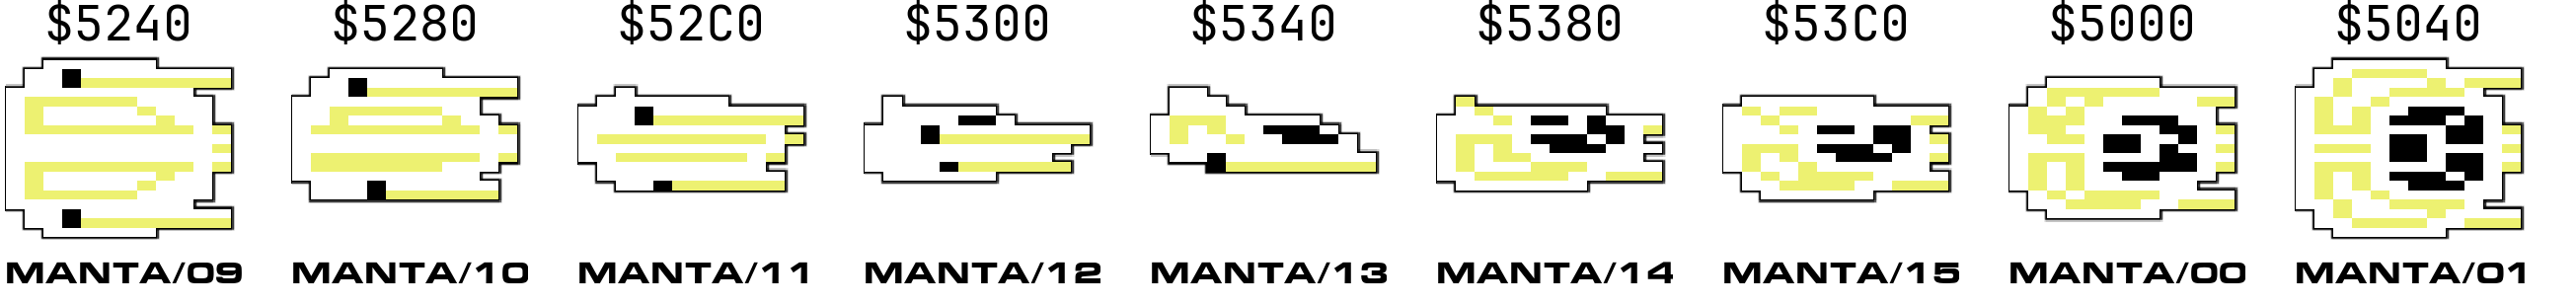

In [25]:
all_sprites = sprite_images[9:16] + sprite_images[0:2]

master_img = Image.new( 'RGBA', (master_width, master_height))

x_offset = 5
img_num = 9
RAM = 0x5240
for img in all_sprites:
    scaled_img = img.resize((SPRITE_WIDTH_SCALED, SPRITE_HEIGHT_SCALED), Image.NEAREST)

    label_text = f"MANTA/{('0'+str(img_num))[-2:]}"
    txt = Image.new('RGBA', (240, 25))
    draw_label = ImageDraw.Draw(txt)
    draw_label.text((0, 0), label_text, font=label_fnt, fill="black")
    master_img.paste(txt, (x_offset, CELL_HEIGHT - 45))

    label_text = f"${hex(RAM)[2:].upper()}"
    txt = Image.new('RGBA', (270, 55))
    draw_label = ImageDraw.Draw(txt)
    draw_label.text((0, 0), label_text, font=ram_fnt, fill="black")
    master_img.paste(txt, (x_offset+40, -10))
    
    master_img.paste(scaled_img, (x_offset,PADDING))

    x_offset += SPRITE_WIDTH_SCALED + 50
    img_num += 1
    RAM += 0x40
    if img_num == 16:
        img_num = 0
        RAM = 0x5000

master_img.save(f"manta_spin_diagrams/manta_spin_second_half.png")
master_img


In [226]:
0xbf

191

In [230]:
(256 - 0xbf) 

65

# Scratchpad